# Predicting Red Wine Quality

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import itertools

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import learning_curve, validation_curve, train_test_split, KFold, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV, cross_validate, RepeatedStratifiedKFold
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier

from scipy.stats import loguniform, beta, uniform

from mlxtend.feature_selection import SequentialFeatureSelector as SFS

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as IMBPipeline

import missingno as msno

import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

## 2. Exploring the Raw Data  and Understanding the Dataset

- load the dataset from a CSV file

In [2]:
df = pd.read_csv('/work/20250213-160813/winequality-red.csv')

In [3]:
# View top 5 rows of the dataset
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
# Checking number of rows and columns of the dataset using shape
print("Number of rows are: ",df.shape[0])
print("Number of columns are: ",df.shape[1])

Number of rows are:  1599
Number of columns are:  12


In [5]:
# Dataset Columns
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

To better understand the dataset, we use histograms to visualize the distribution of numerical variables. Each histogram represents the distribution of a specific feature (column). The x-axis represents the range of values for the feature, while the y-axis shows the frequency (number of occurrences) of those values.

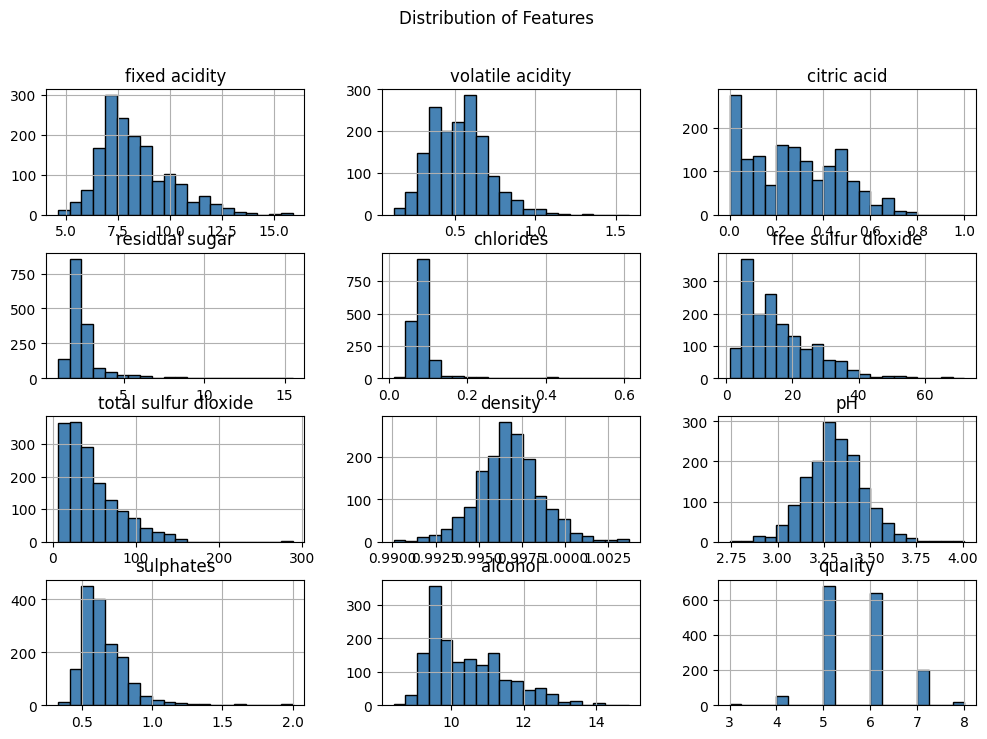

In [6]:
df.hist(figsize=(12, 8), bins=20, color='steelblue', edgecolor='black')
plt.suptitle("Distribution of Features")
plt.show()

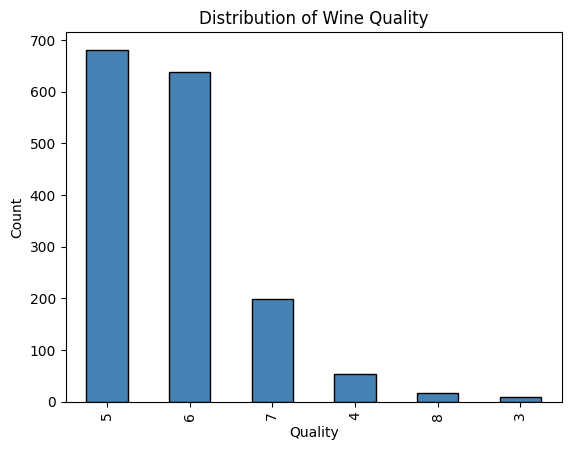

In [7]:
df['quality'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

From this chart, we can clearly see that the data is unbalanced, with most wines having a quality score of 5 or 6, while the classes 3, 4, 7, and 8 are significantly underrepresented.

In [8]:
# Missing Values/Null Values Count
df.isnull().sum()
# All values are 0, so we can proceed to check for duplicates

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [9]:
# Dataset Duplicate Value Count
dup = df.duplicated().sum()
print(f'number of duplicated rows are {dup}')

number of duplicated rows are 240


In [10]:
# Since there are 240 duplicate rows, remove them using the drop_duplicates() function
df_cleaned = df.drop_duplicates()
print(f'Number of rows after removing duplicates: {df_cleaned.shape[0]}')

Number of rows after removing duplicates: 1359


- Separate features (X) and target variable (y)

In [11]:
X = df.drop(['quality'], axis=1)  # holds the features (input data)
y = df['quality']  # holds the target variable (quality)

- X contains all the features (independent variables) except for the target variable quality 

-  The variable y will hold the target values (dependent variable) that need to be predicted.

In [12]:
# Convert quality scores into binary classes (good quality or bad quality)
y = y.apply(lambda x: 1 if x >= 6 else 0)

## 3. Preprocessing Pipeline

Prepare the numerical features to ensure consistency and improve model performance.

In [13]:
pipeline_numeric = Pipeline([  
    ('scaler', StandardScaler())  # standardization: We apply StandardScaler() to normalize numerical features.
])

# preprocessing to the numerical features in our dataset using ColumnTransformer
final_transformation = ColumnTransformer(
    transformers=[('num', pipeline_numeric, X.columns)],  # apply the numeric pipeline to all columns in X
    remainder='drop',  
    verbose_feature_names_out=False,
    sparse_threshold=0
)

## 4. Training and Test Sets

Before training the model, split the dataset into two parts:

- Training set (80%): Used to train the model.

- Testing set (20%): Used to evaluate the model's performance on unseen data.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 5. Model Selection

Now we define a starting model/ pipeline that automates key preprocessing steps, handles class imbalance, reduces dimensionality, and trains a classifier.

In [15]:
model_pipeline = IMBPipeline([
    ('trans', final_transformation),  
    ('sampler', SMOTE()),  
    ('dim_reduction', PCA(n_components=0.95)),  
    ('classifier', RandomForestClassifier(   # Random Forest classifier is used to make predictions while preventing overfitting.
        n_estimators=100,  # number of trees in the forest
        max_depth=8,  # reduced depth for avoid overfitting
        min_samples_split=10,  
        min_samples_leaf=5, 
        class_weight='balanced',  # adjusts weights to handle class imbalance
        random_state=42
    ))
])

Random Forest is the best classifier to use in this dataset because it is a robust ensemble method that reduces overfitting. 

To handle class imbalance, SMOTE (Synthetic Minority Over-sampling Technique) needs to be applied before training, another useful techinoque is to set class_weight='balanced' in Random Forest, so the model assigns higher weights to underrepresented classes. Additionally, PCA is used to reduce dimensionality, helping improve efficiency while retaining 95% of the variance. The combination of SMOTE, PCA, and Random Forest ensures a well-balanced, optimized model that performs effectively on unbalanced datasets.

Now that the pipeline is ready, train the model on the training set and use it to make predictions on the test set.

In [16]:
model_pipeline.fit(X_train, y_train)  # train the entire pipeline

Pipeline(steps=[('trans',
                 ColumnTransformer(sparse_threshold=0,
                                   transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('sampler', SMOTE()), ('dim_reduction', PCA(n_components=0.95)),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=5,
                                        min_samples_split=10,
                                        random_state=42))])

In [17]:
model_pipeline.predict(X_test) # generate predictions

array([0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,

In [18]:
y_pred = model_pipeline.predict(X_test)  # uses the trained model to make predictions on the test data
# `X_test` contains only the features, without labels
# `y_pred` will be an array with the predicted labels from the model

it's crucial to explore different combinations of key components: sampling strategies, dimensionality reduction techniques, and classifiers. This allows to identify the best configuration that yields the highest performance.

In [19]:
sampler_configs = [
    {
        'sampler':[None],# The element is bypassed
    },
    {
        'sampler':[SMOTE(n_jobs=-1)],
        'sampler__sampling_strategy':['minority', 1.2, 0.9, 0.7]
    },
    {
        'sampler':[RandomOverSampler()],
        'sampler__sampling_strategy':['minority', 1.2, 0.9, 0.7]
    }
]

dim_reduction_configs = [
    {
        'dim_reduction': [None]
    },
    {
        'dim_reduction': [PCA()],
        'dim_reduction__n_components': [0.5, 0.7, 0.9]
    },
    {
        'dim_reduction': [LDA()]
    },
    {
        'dim_reduction': [SFS(estimator=Perceptron(), cv = None, scoring = 'f1')],
        'dim_reduction__estimator': [Perceptron(), LogisticRegression()],
        'dim_reduction__k_features' : [5,7,10]  
    }
]

classifier_configs = [
    {
        'classifier__eta0' : loguniform(0.001,100),
        'classifier': [Perceptron()] ,
        'classifier__max_iter': [1,5,10,15,50,100] ,
        'classifier__class_weight' : [None, 'balanced']

    },
    {
        'classifier': [LogisticRegression(solver='saga')],
        'classifier__C' : loguniform(0.001,100),
        'classifier__penalty': ['l1','l2'],
        'classifier__class_weight' : [None, 'balanced']

    },
    {
        'classifier': [KNeighborsClassifier()],
        'classifier__n_neighbors': [3,5,7,9]
    },
    {
        'classifier' : [RandomForestClassifier()],
        'classifier__n_estimators' : [10,50,100, 500]
    }
]

Build a list of all possible configurations to be passed to RandomSearchCV object.

In [20]:
all_configs = [dict(itertools.chain(*(e.items() 
for e in configuration))) 
for configuration in 
itertools.product(sampler_configs,dim_reduction_configs,classifier_configs)]

In [21]:
f'Number of all possible configurations: {len(all_configs)}'

'Number of all possible configurations: 48'

In [22]:
all_configs[:2]

[{'sampler': [None],
  'dim_reduction': [None],
  'classifier__eta0': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x7fb015d48430>,
  'classifier': [Perceptron()],
  'classifier__max_iter': [1, 5, 10, 15, 50, 100],
  'classifier__class_weight': [None, 'balanced']},
 {'sampler': [None],
  'dim_reduction': [None],
  'classifier': [LogisticRegression(solver='saga')],
  'classifier__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x7fb015d49960>,
  'classifier__penalty': ['l1', 'l2'],
  'classifier__class_weight': [None, 'balanced']}]

## 6. Model Selection with Nested-Cross Validation

Use RandomizedSearchCV to sample a subset of hyperparameter combinations

In [23]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'classifier__n_estimators': [100, 200],   # Number of trees in the forest (100 or 200).
    'classifier__max_depth': [5, 10, 15],   # Maximum depth of each tree (5, 10, or 15).
    'classifier__min_samples_split': [2, 5, 10],   # Minimum number of samples required to split a node (2, 5, or 10).
    'classifier__min_samples_leaf': [1, 2, 4],   # Minimum number of samples required to be at a leaf node (1, 2, or 4).
}


In [24]:
rs = RandomizedSearchCV(model_pipeline,   # performs hyperparameter optimization by randomly selecting combinations from param_dist
    param_distributions=param_dist,
    n_iter=len(all_configs) * 5,
    n_jobs=-1,
    cv=5,
    scoring='f1'
)
# the goal is to find the best combination of hyperparameters to maximize performance

After defining and applying RandomizedSearchCV,  now use cross-validation to get a more reliable estimate of the model’s performance.

In [25]:
scores = cross_validate(rs, X_train, y_train, scoring='f1', cv = 5, return_estimator=True, verbose=3) 

[CV] END ......................................., score=0.781 total time= 1.6min
[CV] END ......................................., score=0.778 total time= 1.7min
[CV] END ......................................., score=0.797 total time= 1.7min
[CV] END ......................................., score=0.822 total time= 1.7min
[CV] END ......................................., score=0.858 total time= 1.7min


The results from the 5-fold cross-validation provide an estimate of how well our model generalizes to unseen data. Each score represents the F1-score for one of the five validation folds. The scores range indicates that the model maintains strong predictive performance across different data splits.

In [26]:
# calculate the average F1 score
f1_scores = scores['test_score']
average_f1 = np.mean(f1_scores)
print(f"Media F1 Score: {average_f1:.4f}")

Media F1 Score: 0.8073


The average F1-score across the five folds indicates a well-performing model with balanced precision and recall.

After obtaining the F1-scores from cross-validation, it's important to further evaluate the model's performance using different metrics:

- Accuracy → Measures overall correctness

- Recall → Measures the model’s ability to correctly identify positive cases

- Confusion Matrix → Provides a detailed breakdown of correct and incorrect classifications.

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7438


In [28]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

Recall: 0.7151


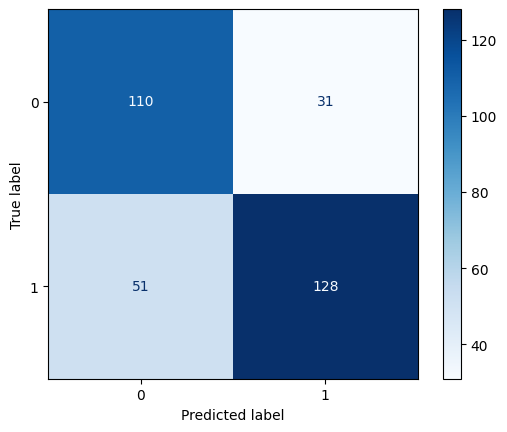

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(y_test, y_pred)

# plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')  
plt.show()



Overall, the model is performing well.

Analysis of Hyperparameter Tuning and F1 Scores

Examine the output format and create a for loop that visualizes each step of the model pipeline along with the final score, providing a clear overview of the best models' performances.

In [30]:
for index, estimator in enumerate(scores['estimator']):
    print(estimator.best_estimator_.get_params()['sampler'])
    print(estimator.best_estimator_.get_params()['dim_reduction'])
    print(estimator.best_estimator_.get_params()['classifier'],estimator.best_estimator_.get_params()['classifier'].get_params())
    print(scores['test_score'][index])
    print('-'*10)

SMOTE()
PCA(n_components=0.95)
RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_split=5, n_estimators=200, random_state=42) {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 15, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
0.781021897810219
----------
SMOTE()
PCA(n_components=0.95)
RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42) {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_

In [31]:
for estimator in scores['estimator']:
    pred_train = estimator.best_estimator_.fit(X_train, y_train)
    pred_train = estimator.best_estimator_.predict(X_train)
    pred_test = estimator.best_estimator_.predict(X_test)
    f1_train = f1_score(y_train, pred_train)
    f1_test = f1_score(y_test, pred_test)
    print(f'F1 on training set:{f1_train}, F1 on test set:{f1_test}')

F1 on training set:0.999259807549963, F1 on test set:0.8
F1 on training set:0.9813293502613891, F1 on test set:0.7942028985507247
F1 on training set:0.9828230022404779, F1 on test set:0.8160919540229885
F1 on training set:1.0, F1 on test set:0.8160919540229885
F1 on training set:1.0, F1 on test set:0.8022598870056498


## 7. Refinement of the Selected Model

In the final step of model selection, we perform a hyperparameter optimization to refine the model and improve its performance. After selecting the best candidate model, we re-run the optimization process by fixing the model type and varying its hyperparameters

In [32]:
best_model_pipeline = IMBPipeline([
    ('trans', final_transformation),
    ('classifier',LogisticRegression(solver='saga', penalty = 'l1'))
])

In [33]:
params = {
    'classifier__C': uniform(loc = 5, scale = 10)
}

In [34]:
rs_best = RandomizedSearchCV(
    estimator = best_model_pipeline,
    param_distributions = params,
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=1),
    n_iter=20,
    scoring='f1'
)

In this case, use Logistic Regression with L1 regularization, and apply RandomizedSearchCV for hyperparameter optimization, using cross-validation to ensure the model’s robustness and reliability.

In [35]:
rs_best.fit(X_train, y_train) # train the model with the best hyperparameters found during the RandomizedSearchCV process

RandomizedSearchCV(cv=RepeatedStratifiedKFold(n_repeats=1, n_splits=5, random_state=None),
                   estimator=Pipeline(steps=[('trans',
                                              ColumnTransformer(sparse_threshold=0,
                                                                transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object'))],
                                                                verbose_feature_names_out=False)),
                                             ('classifier',
                                              LogisticRegression(penalty='l1',
                                                                 solver='saga'))]),
                   n_iter=20,
                   param_distributions={'classifier__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7fb01a16d930>},
                   scoring='f1')

In [36]:
rs_best.best_estimator_   

Pipeline(steps=[('trans',
                 ColumnTransformer(sparse_threshold=0,
                                   transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('classifier',
                 LogisticRegression(C=5.833241685977306, penalty='l1',
                                    solver='saga'))])

In [37]:
f1_score(y_test, rs_best.best_estimator_.predict(X_test))

0.760806916426513

Now, visualize the learning curve and the validation curve to assess the bias-variance trade-off by varying the size of the training set and the hyperparameter C for Logistic Regression.

In [38]:
cls = rs_best.best_estimator_

In [39]:
train_sizes, train_scores, test_scores = learning_curve(cls,
                                                       X=X_train,
                                                       y=y_train,
                                                       train_sizes= [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                                                       cv = 5,
                                                       n_jobs = -1,
                                                       scoring = 'f1',
                                                       shuffle = False)

(0.6, 1.03)

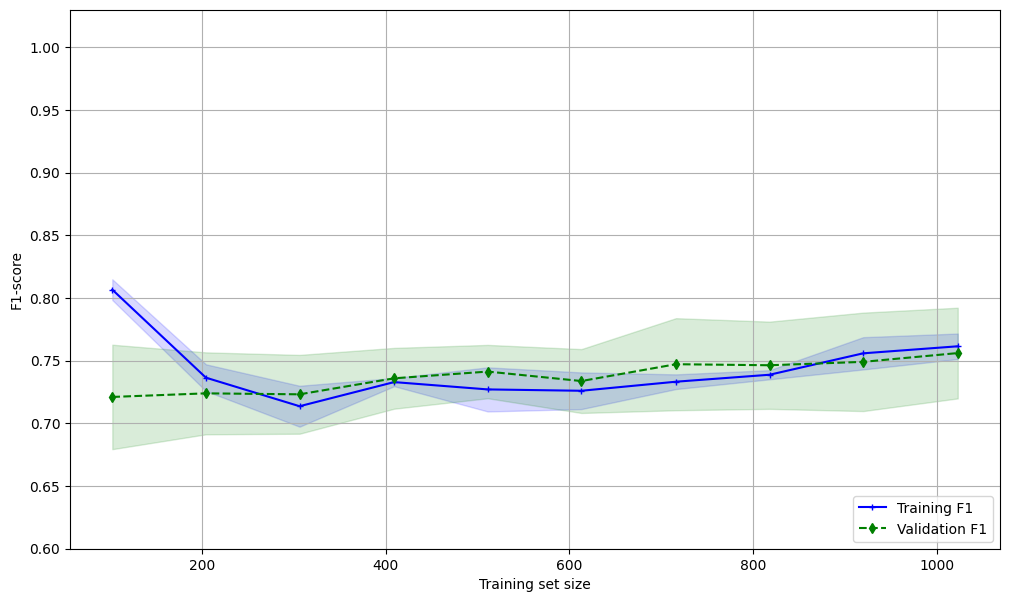

In [40]:
# learning curve plot showing the F1-score as a function of the training set size
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

fig=plt.figure(figsize=(12,7))
ax = fig.add_subplot()

ax.plot(train_sizes, train_mean,
         color='blue', marker='+',
         markersize=5, label='Training F1')

ax.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

ax.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='d', markersize=5,
         label='Validation F1')

ax.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

ax.grid()
ax.set_xlabel('Training set size')
ax.set_ylabel('F1-score')
ax.legend(loc='lower right')
ax.set_ylim([0.60, 1.03])

- The model is not overfitting, as the gap between training and validation scores is small.

- As the training set size increases, generalization improves, reducing the gap between training and validation F1-scores.

In [41]:
range_C = [0.001,0.01,0.1,1,10,100]
train_scores, test_scores = validation_curve(cls,
        X=X_train, 
        y=y_train, 
        param_range=
        range_C, 
        param_name='classifier__C',
        cv=5, 
        n_jobs=-1, 
        scoring='f1'
)

(0.05, 100)

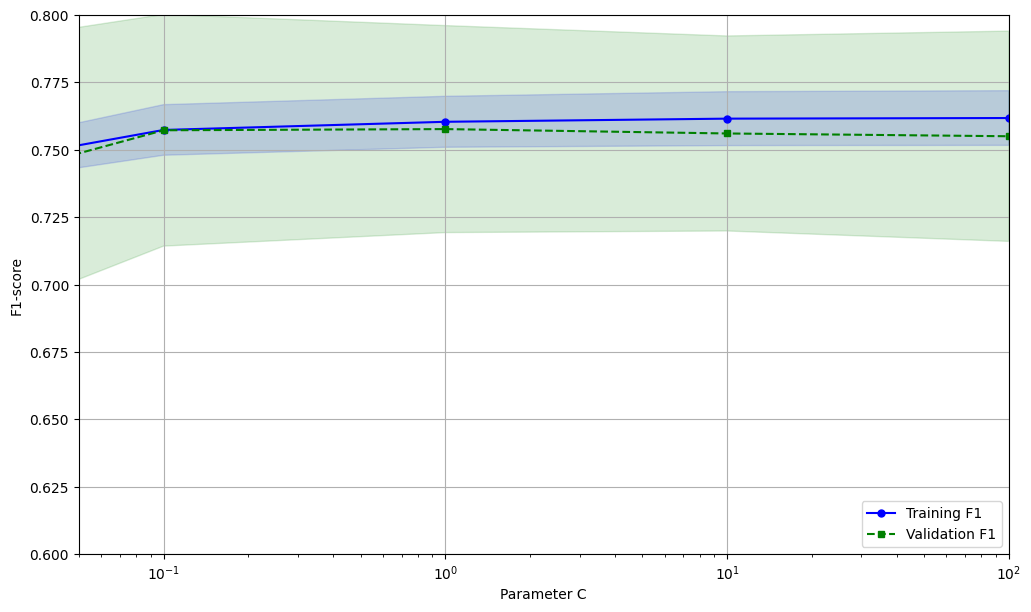

In [42]:
# validation curve plot showing the F1-score as a function of the hyperparameter C for a classifier.
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

fig=plt.figure(figsize=(12,7))
ax = fig.add_subplot()
ax.plot(range_C, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training F1')

ax.fill_between(range_C,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

ax.plot(range_C, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation F1')

ax.fill_between(range_C,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

ax.grid()
ax.set_xlabel('Parameter C')
ax.set_ylabel('F1-score')
ax.legend(loc='lower right')
ax.set_ylim([0.6, 0.8])
ax.set_xscale('log')
ax.set_xlim([0.05,100])

- The Training and Validation F1-scores are very close, indicating that the model generalizes well for all values of C.

- Since the Training and Validation F1-scores remain close, the model is well-regularized and avoids overfitting or underfitting.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=27aebd70-c529-4621-bdcf-b4f458cebd47' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>